# Class Imbalance

This notebook focuses on different options to handle target class imbalance in https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv dataset and its results.

The previous notebooks related to modeling and result analysis can be found by links:
 - https://github.com/Maxstef/ml-bank-additional-project/blob/main/notebooks/03_modeling.ipynb
 - https://github.com/Maxstef/ml-bank-additional-project/blob/main/notebooks/04_model_analysis.ipynb


## Notebook initialization

In [1]:
# Notebook initialization
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd()

while not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# print("Project root:", ROOT)

## Imports & Load data

During experiments use:
- The two best-performing models based on F1 score from the modeling stage: XGBoost and Random Forest
- A non–tree-based model (Logistic Regression) to provide a comparison with the top-performing tree-based models

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score

from src.data import load_raw_data

raw_df = load_raw_data()
raw_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
target_col = "y"

## Split Data Train & Validation

In [4]:
from src.data import split_train_val, split_X_y

train_df, val_df = split_train_val(raw_df, stratify_col=target_col)

X_train, X_val, y_train, y_val = split_X_y(train_df, val_df, target_col)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((32950, 20), (8238, 20), (32950,), (8238,))

## Experiments Preparation & Results Tracking

Use the same experiments framework as in <a href="https://github.com/Maxstef/ml-bank-additional-project/blob/main/notebooks/03_modeling.ipynb">modeling notebook</a> to track and compare all experiments results 

In [5]:
from src.modeling.experiments import train_pipeline, show_results_df
from src.pipelining import build_pipeline

## Previous Best Models

Build best previously found options for each model

In [6]:
random_state = 42

log_reg_params = {
    "soceco_bin_cols": ["emp.var.rate", "cons.price.idx", "cons.conf.idx"],
    "calendar_cols_mode": "onehot",
    "poly_degree": 1,
    "age_bin_mode": "group",
    "pdays_transform_mode": "group",
    "drop_cols": ["duration", "loan", "housing", "euribor3m"],
}
log_reg_hyperparams = {"solver": "liblinear", "l1_ratio": 1, "C": 0.05, "class_weight": {"yes": 4, "no": 1}}
log_reg_params["model"] = LogisticRegression(**log_reg_hyperparams, random_state=random_state)

rf_params = {
    "drop_cols": ["duration"]
}
rf_hyperparams = {'class_weight': {'no': 1, 'yes': 4}, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 100}
rf_params["model"] = RandomForestClassifier(**rf_hyperparams, random_state=random_state)

xgb_params = {
    "pdays_transform_mode": "group",
    "drop_cols": ["duration", "loan", "housing", "euribor3m"],
}
xgb_hyperparams = {'colsample_bytree': 0.827313978086766, 'learning_rate': 0.09198815138814205, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 100, 'scale_pos_weight': 4, 'subsample': 0.8977551500793569}
xgb_params["model"]  = XGBClassifier(**xgb_hyperparams, random_state=random_state)

y_train_bin = y_train.map({"no": 0, "yes": 1})
y_val_bin = y_val.map({"no": 0, "yes": 1})

params_options = [log_reg_params, rf_params, xgb_params]

log_reg_pipe = train_pipeline(X_train, X_val, y_train, y_val,
    log_reg_params
)

rf_pipe = train_pipeline(X_train, X_val, y_train, y_val,
    rf_params
)

xgb_pipe = train_pipeline(X_train, X_val, y_train_bin, y_val_bin,
    xgb_params
)

show_results_df()

,model_name,fit_time,train_f1,val_f1,train_auroc,val_auroc
1,RandomForestClassifier,1.280408,0.536418,0.535487,0.929622,0.805560
2,XGBClassifier,0.213312,0.517778,0.534227,0.841017,0.806580
0,LogisticRegression,0.827581,0.484128,0.506961,0.792412,0.800878


## Class balancing with models hyperparams

### Logistic Regression class_weight

In [7]:
class_weight_options = [
    None, "balanced",
    {"yes": 2, "no": 1}, {"yes": 3, "no": 1},
    {"yes": 4, "no": 1}, {"yes": 5, "no": 1},
    {"yes": 6, "no": 1}, {"yes": 7, "no": 1},
    {"yes": 8, "no": 1}, {"yes": 9, "no": 1},
    {"yes": 10, "no": 1}, {"yes": 11, "no": 1},
]

log_reg_preds = {}

for class_weight in class_weight_options:
    log_reg_hyperparams_curr = log_reg_hyperparams.copy()
    log_reg_params_curr = log_reg_params.copy()

    log_reg_hyperparams_curr["class_weight"] = class_weight

    log_reg_params_curr["model"] = LogisticRegression(**log_reg_hyperparams_curr, random_state=random_state)

    log_reg_pipe = train_pipeline(X_train, X_val, y_train, y_val,
        log_reg_params_curr
    )

    log_reg_pred = log_reg_pipe.predict(X_val)

    log_reg_preds[str(class_weight)] = log_reg_pred

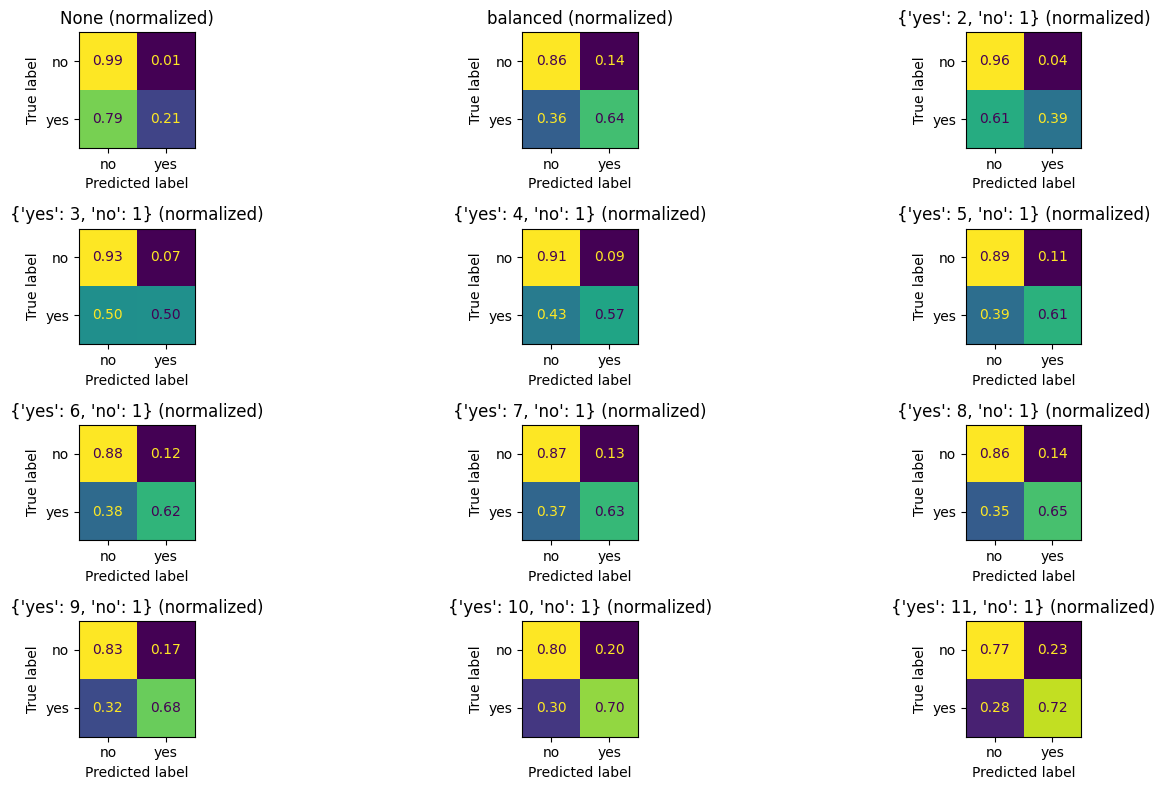

In [8]:
from src.analysis.utils import plot_confusion_matrices

plot_confusion_matrices(y_val, log_reg_preds, normalize="true")

In [9]:
show_results_df(
    model_name="LogisticRegression",
    show_cols=[
        "model_name", "model__class_weight", "fit_time",
        "train_f1","val_f1",
        "train_auroc","val_auroc",
        "train_recall","val_recall",
        "train_precision","val_precision",
    ],
    show_count=20
)

,model_name,model__class_weight,fit_time,train_f1,val_f1,train_auroc,val_auroc,train_recall,val_recall,train_precision,val_precision
0,LogisticRegression,"{'yes': 4, 'no': 1}",0.827581,0.484128,0.506961,0.792412,0.800878,0.548491,0.568966,0.433284,0.457143
7,LogisticRegression,"{'yes': 4, 'no': 1}",0.864462,0.484128,0.506961,0.792412,0.800878,0.548491,0.568966,0.433284,0.457143
8,LogisticRegression,"{'yes': 5, 'no': 1}",1.239576,0.477576,0.500883,0.792687,0.800978,0.583782,0.610991,0.404065,0.424401
6,LogisticRegression,"{'yes': 3, 'no': 1}",0.642988,0.475782,0.489261,0.791843,0.800646,0.493534,0.503233,0.459263,0.476045
9,LogisticRegression,"{'yes': 6, 'no': 1}",0.672177,0.467557,0.485593,0.792917,0.801136,0.594019,0.617457,0.385490,0.400140
10,LogisticRegression,"{'yes': 7, 'no': 1}",1.107542,0.460433,0.476620,0.793139,0.801363,0.604256,0.626078,0.371912,0.384768
11,LogisticRegression,"{'yes': 8, 'no': 1}",1.045902,0.447949,0.466848,0.793287,0.801483,0.623653,0.648707,0.349487,0.364627
4,LogisticRegression,balanced,0.459149,0.446985,0.466354,0.792501,0.801343,0.616110,0.642241,0.350713,0.366093
5,LogisticRegression,"{'yes': 2, 'no': 1}",0.546783,0.447421,0.453803,0.790948,0.800265,0.391433,0.389009,0.522098,0.544495
12,LogisticRegression,"{'yes': 9, 'no': 1}",1.303729,0.431025,0.449038,0.793405,0.801600,0.648976,0.678879,0.322663,0.335463


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Confusion Logistic Regression - class_weight**

 - Best configuration: class_weight = {'yes': 4, 'no': 1}
    - Highest F1 ≈ 0.507 with a good balance of precision (~0.457) and recall (~0.569)
 - Increasing class_weight:
    - Increases recall
    - Decreases precision
    - F1 peaks around weights 3–5, then declines
 - Balanced class_weight:
    - Performs worse than the best tuned weights in terms of F1
 - No class_weight:
    - Very low recall and low F1, model is biased toward the majority class
 - AUROC stays roughly constant (~0.80) across all runs:
    - Class_weight mainly affects the decision threshold, not ranking quality
 - Overall:
    - Moderate class_weight gives the best trade-off
    - Extreme weights hurt precision and overall F1

</span>

### Random Forest class_weight

In [10]:
for class_weight in class_weight_options:
    rf_hyperparams_curr = rf_hyperparams.copy()
    rf_params_curr = rf_params.copy()

    rf_hyperparams_curr["class_weight"] = class_weight

    rf_params_curr["model"] = RandomForestClassifier(**rf_hyperparams_curr, random_state=random_state)

    train_pipeline(X_train, X_val, y_train, y_val,
        rf_params_curr
    )   

In [11]:
show_results_df(
    model_name="RandomForestClassifier",
    show_cols=[
        "model_name", "model__class_weight", "fit_time",
        "train_f1","val_f1",
        "train_auroc","val_auroc",
        "train_recall","val_recall",
        "train_precision","val_precision",
    ],
    show_count=20
)

,model_name,model__class_weight,fit_time,train_f1,val_f1,train_auroc,val_auroc,train_recall,val_recall,train_precision,val_precision
1,RandomForestClassifier,"{'no': 1, 'yes': 4}",1.280408,0.536418,0.535487,0.929622,0.805560,0.590248,0.589440,0.491586,0.490583
19,RandomForestClassifier,"{'yes': 4, 'no': 1}",1.169357,0.536418,0.535487,0.929622,0.805560,0.590248,0.589440,0.491586,0.490583
20,RandomForestClassifier,"{'yes': 5, 'no': 1}",1.171412,0.531213,0.530166,0.930718,0.805617,0.607489,0.601293,0.471955,0.474087
21,RandomForestClassifier,"{'yes': 6, 'no': 1}",1.163903,0.534236,0.529575,0.931132,0.805871,0.627425,0.617457,0.465149,0.463592
22,RandomForestClassifier,"{'yes': 7, 'no': 1}",1.231493,0.541449,0.522923,0.931839,0.806087,0.655442,0.620690,0.461232,0.451765
18,RandomForestClassifier,"{'yes': 3, 'no': 1}",1.178647,0.551492,0.521875,0.928546,0.806073,0.572737,0.539871,0.531766,0.505040
23,RandomForestClassifier,"{'yes': 8, 'no': 1}",1.166321,0.548436,0.520267,0.932330,0.808914,0.680226,0.629310,0.459425,0.443432
16,RandomForestClassifier,balanced,1.118795,0.547199,0.520231,0.932369,0.806676,0.676185,0.630388,0.459539,0.442846
24,RandomForestClassifier,"{'yes': 9, 'no': 1}",1.220809,0.557919,0.511101,0.932605,0.807088,0.713631,0.632543,0.457988,0.428780
25,RandomForestClassifier,"{'yes': 10, 'no': 1}",1.157869,0.564653,0.508330,0.933166,0.807023,0.744073,0.641164,0.454950,0.421090


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Confusion Random Forest - class_weight**


* Best configuration: class_weight = {'no': 1, 'yes': 4}

  * Highest F1 ≈ 0.535 with balanced precision (~0.491) and recall (~0.589)

* Increasing class_weight:

  * Increases recall
  * Decreases precision
  * F1 peaks around weights 3–4, then declines

* Balanced class_weight:

  * Slightly worse than the best tuned weights (~0.520 F1)

* No class_weight:

  * Very low recall and F1
  * High precision, model biased toward majority class

* AUROC remains stable (~0.805–0.808):

  * Class_weight mainly affects threshold behavior, not ranking

* Overall:

  * Moderate class_weight (~3–4) gives the best trade-off
  * Extreme weights hurt precision and F1

</span>

### XGB scale_pos_weight

In [12]:
scale_pos_weight_options = [
    None, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11
]

for scale_pos_weight in scale_pos_weight_options:
    xgb_hyperparams_curr = xgb_hyperparams.copy()
    xgb_params_curr = xgb_params.copy()

    xgb_hyperparams_curr["scale_pos_weight"] = scale_pos_weight

    xgb_params_curr["model"] = XGBClassifier(**xgb_hyperparams_curr, random_state=random_state)

    train_pipeline(X_train, X_val, y_train_bin, y_val_bin,
        xgb_params_curr
    )    

In [13]:
show_results_df(
    model_name="XGBClassifier",
    show_cols=[
        "model_name", "model__scale_pos_weight", "fit_time",
        "train_f1","val_f1",
        "train_auroc","val_auroc",
        "train_recall","val_recall",
        "train_precision","val_precision",
    ],
    show_count=20
)

,model_name,model__scale_pos_weight,fit_time,train_f1,val_f1,train_auroc,val_auroc,train_recall,val_recall,train_precision,val_precision
2,XGBClassifier,4.0,0.213312,0.517778,0.534227,0.841017,0.806580,0.578664,0.601293,0.468484,0.480620
30,XGBClassifier,4.0,0.197588,0.517778,0.534227,0.841017,0.806580,0.578664,0.601293,0.468484,0.480620
31,XGBClassifier,5.0,0.214150,0.512351,0.526121,0.841894,0.806145,0.595097,0.613147,0.449807,0.460729
32,XGBClassifier,6.0,0.222729,0.508112,0.519187,0.842812,0.807678,0.607489,0.619612,0.436677,0.446775
29,XGBClassifier,3.0,0.286892,0.530597,0.516751,0.839021,0.806112,0.557112,0.548491,0.506490,0.488484
33,XGBClassifier,7.0,0.219078,0.497957,0.501074,0.843144,0.805803,0.623653,0.628233,0.414429,0.416726
28,XGBClassifier,2.0,0.214693,0.531880,0.494076,0.834613,0.808393,0.479795,0.449353,0.596650,0.548684
34,XGBClassifier,8.0,0.205299,0.487304,0.485890,0.842893,0.806062,0.646282,0.640086,0.391099,0.391562
35,XGBClassifier,9.0,0.213358,0.475706,0.468462,0.844109,0.806161,0.667295,0.656250,0.369591,0.364234
36,XGBClassifier,10.0,0.195420,0.460375,0.453855,0.844790,0.805407,0.688578,0.675647,0.345779,0.341689


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Confusion XGBoost - scale_pos_weight**

* Best configuration: scale_pos_weight = 4.0

  * Highest F1 ≈ 0.534 with good balance of precision (~0.481) and recall (~0.601)

* Increasing scale_pos_weight:

  * Increases recall
  * Decreases precision
  * F1 peaks around 3–4, then declines

* Lower weights (2–3):

  * Higher precision
  * Lower recall
  * Slightly lower F1

* Higher weights (≥6):

  * Recall increases further
  * Precision drops significantly
  * F1 decreases

* No scale_pos_weight:

  * Very low recall and lowest F1
  * High precision, biased toward majority class

* AUROC remains stable (~0.805–0.808):

  * Mainly affects decision threshold, not ranking

* Overall:

  * Moderate scale_pos_weight (~3–4) gives the best trade-off
  * Extreme values hurt precision and F1

</span>

## Class balancing with re-sampling techniques

### Logisting Regression

In [14]:
sampler_options = [None, "smote", "adasyn", "random_over", "random_under", "tomek", "smote_tomek"]
class_weight_short_options = [None, "balanced", {"yes": 4, "no": 1}]

for sampler_name in sampler_options:
    for class_weight in class_weight_short_options:
        log_reg_hyperparams_curr = log_reg_hyperparams.copy()
        log_reg_params_curr = log_reg_params.copy()

        log_reg_hyperparams_curr["class_weight"] = class_weight

        log_reg_params_curr["model"] = LogisticRegression(**log_reg_hyperparams_curr, random_state=random_state)
        log_reg_params_curr["sampler_name"] = sampler_name

        train_pipeline(X_train, X_val, y_train, y_val,
            log_reg_params_curr
        )    


In [15]:
show_results_df(
    model_name="LogisticRegression",
    show_cols=[
        "model_name", "model__class_weight", "pipe__sampler_name",  "fit_time",
        "train_f1","val_f1",
        "train_auroc","val_auroc",
        "train_recall","val_recall",
        "train_precision","val_precision",
    ],
    show_count=30,
    min_experiment_id=40,
)

,model_name,model__class_weight,pipe__sampler_name,fit_time,train_f1,val_f1,train_auroc,val_auroc,train_recall,val_recall,train_precision,val_precision
55,LogisticRegression,"{'yes': 4, 'no': 1}",tomek,1.549599,0.484034,0.507123,0.792365,0.800925,0.553341,0.575431,0.430157,0.453311
40,LogisticRegression,"{'yes': 4, 'no': 1}",None,0.821675,0.484128,0.506961,0.792412,0.800878,0.548491,0.568966,0.433284,0.457143
47,LogisticRegression,NaN,random_over,1.838846,0.452759,0.470635,0.793275,0.801512,0.617726,0.643319,0.357332,0.371038
48,LogisticRegression,balanced,random_over,1.845008,0.452759,0.470635,0.793275,0.801512,0.617726,0.643319,0.357332,0.371038
54,LogisticRegression,balanced,tomek,1.151898,0.447790,0.465335,0.792445,0.801422,0.616918,0.640086,0.351443,0.365538
42,LogisticRegression,balanced,smote,2.116794,0.442935,0.461073,0.792088,0.799534,0.632543,0.657328,0.340784,0.355064
57,LogisticRegression,balanced,smote_tomek,3.760038,0.442935,0.461073,0.792077,0.799491,0.632543,0.657328,0.340784,0.355064
56,LogisticRegression,NaN,smote_tomek,3.905757,0.442935,0.461073,0.792077,0.799491,0.632543,0.657328,0.340784,0.355064
41,LogisticRegression,NaN,smote,2.147728,0.442935,0.461073,0.792088,0.799534,0.632543,0.657328,0.340784,0.355064
50,LogisticRegression,NaN,random_under,0.172438,0.443450,0.456614,0.788173,0.797540,0.614224,0.637931,0.346979,0.355556


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Confusion Logistic Regression - re-sampling**

* Best overall configuration remains: class_weight = {'yes': 4, 'no': 1} (with or without Tomek)

  * Highest F1 ≈ 0.507
  * Stable precision (~0.45) and recall (~0.57)
  * Tomek Links has negligible impact on performance

* Resampling without class_weight:

  * random_over:

    * Best among resampling-only methods (val_f1 ≈ 0.471)
    * Higher recall (~0.64) but lower precision (~0.37)
    * Closest alternative to class_weight
  * random_under:

    * val_f1 ≈ 0.457
    * Simpler but loses information
  * SMOTE / SMOTE-Tomek:

    * val_f1 ≈ 0.459
    * High recall but low precision (~0.35)
  * ADASYN:

    * Worst among resampling-only (val_f1 ≈ 0.428)
    * Very high recall but very low precision

* Resampling with class_weight:

  * Produces extremely high recall (~0.95–0.98)
  * Precision collapses (~0.12–0.37)
  * Leads to very low F1 → overcorrection

* AUROC remains stable (~0.797–0.802):

  * Methods affect threshold behavior, not ranking quality

* Fit time:

  * SMOTE / ADASYN / SMOTE-Tomek are more expensive
  * random_under is fastest, Tomek adds moderate overhead

* Overall:

  * Class_weight tuning clearly outperforms resampling in F1
  * random_over is the best resampling alternative, but still worse than class_weight
  * Combining resampling + class_weight is not beneficial
  * Best and most stable approach: class_weight = {'yes': 4, 'no': 1}

</span>

### Random Forest

In [16]:
for sampler_name in sampler_options:
    for class_weight in class_weight_short_options:
        rf_hyperparams_curr = rf_hyperparams.copy()
        rf_params_curr = rf_params.copy()

        rf_hyperparams_curr["class_weight"] = class_weight

        rf_params_curr["model"] = RandomForestClassifier(**rf_hyperparams_curr, random_state=random_state)
        rf_params_curr["sampler_name"] = sampler_name

        train_pipeline(X_train, X_val, y_train, y_val,
            rf_params_curr
        )    


In [17]:
show_results_df(
    model_name="RandomForestClassifier",
    show_cols=[
        "model_name", "model__class_weight", "pipe__sampler_name",  "fit_time",
        "train_f1","val_f1",
        "train_auroc","val_auroc",
        "train_recall","val_recall",
        "train_precision","val_precision",
    ],
    show_count=30,
    min_experiment_id=55,
)

,model_name,model__class_weight,pipe__sampler_name,fit_time,train_f1,val_f1,train_auroc,val_auroc,train_recall,val_recall,train_precision,val_precision
61,RandomForestClassifier,"{'yes': 4, 'no': 1}",None,1.182119,0.536418,0.535487,0.929622,0.805560,0.590248,0.589440,0.491586,0.490583
76,RandomForestClassifier,"{'yes': 4, 'no': 1}",tomek,1.697136,0.526492,0.532057,0.926899,0.806566,0.594289,0.599138,0.472579,0.478485
78,RandomForestClassifier,balanced,smote_tomek,4.662825,0.587209,0.528165,0.925804,0.803689,0.598599,0.550647,0.576245,0.507448
77,RandomForestClassifier,NaN,smote_tomek,4.658751,0.587209,0.528165,0.925804,0.803689,0.598599,0.550647,0.576245,0.507448
62,RandomForestClassifier,NaN,smote,3.036293,0.585901,0.524081,0.928116,0.803704,0.596713,0.545259,0.575474,0.504487
63,RandomForestClassifier,balanced,smote,2.961401,0.585901,0.524081,0.928116,0.803704,0.596713,0.545259,0.575474,0.504487
60,RandomForestClassifier,balanced,None,1.178832,0.547199,0.520231,0.932369,0.806676,0.676185,0.630388,0.459539,0.442846
66,RandomForestClassifier,balanced,adasyn,2.977226,0.596640,0.519938,0.931645,0.802707,0.607489,0.540948,0.586171,0.500499
65,RandomForestClassifier,NaN,adasyn,2.956855,0.597275,0.518785,0.931683,0.803313,0.608297,0.543103,0.586646,0.496552
75,RandomForestClassifier,balanced,tomek,1.649051,0.541355,0.514991,0.929636,0.806592,0.672683,0.629310,0.452929,0.435821


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Confusion Random Forest - re-sampling**

* Best overall: RandomForest + class_weight = {'yes': 4, 'no': 1}

  * Highest val_f1 (~0.535) with balanced precision/recall
  * Stable and efficient

* Resampling impact:

  * Generally does not improve F1 over class_weight alone
  * SMOTE / SMOTE-Tomek: similar but slightly worse, higher recall, lower precision
  * random_over: boosts recall but hurts precision → unstable F1
  * random_under: decent and fast, but lower performance ceiling
  * ADASYN: no clear benefit, tends to reduce precision

* Key differences vs Logistic Regression:

  * RandomForest already handles imbalance well with class_weight
  * Resampling adds cost/complexity without meaningful gains
  * Combining class_weight + resampling often degrades results

* Overall:

  * class_weight alone is the best and most robust choice
  * resampling is mostly unnecessary for RandomForest in this setup


</span>

### XGB

In [18]:
scale_pos_weight_short_options = [
    None, 4, 8,
]

for sampler_name in sampler_options:
    for scale_pos_weight in scale_pos_weight_short_options:
        xgb_hyperparams_curr = xgb_hyperparams.copy()
        xgb_params_curr = xgb_params.copy()

        xgb_hyperparams_curr["scale_pos_weight"] = scale_pos_weight

        xgb_params_curr["model"] = XGBClassifier(**xgb_hyperparams_curr, random_state=random_state)
        xgb_params_curr["sampler_name"] = sampler_name

        train_pipeline(X_train, X_val, y_train_bin, y_val_bin,
            xgb_params_curr
        )

In [19]:
show_results_df(
    model_name="XGBClassifier",
    show_cols=[
        "model_name", "model__scale_pos_weight", "pipe__sampler_name",  "fit_time",
        "train_f1","val_f1",
        "train_auroc","val_auroc",
        "train_recall","val_recall",
        "train_precision","val_precision",
    ],
    show_count=30,
    min_experiment_id=55,
)

,model_name,model__scale_pos_weight,pipe__sampler_name,fit_time,train_f1,val_f1,train_auroc,val_auroc,train_recall,val_recall,train_precision,val_precision
81,XGBClassifier,4.0,None,0.260304,0.517778,0.534227,0.841017,0.806580,0.578664,0.601293,0.468484,0.480620
96,XGBClassifier,4.0,tomek,0.775201,0.514758,0.527008,0.840960,0.806813,0.587284,0.604526,0.458176,0.467111
83,XGBClassifier,NaN,smote,0.575459,0.503326,0.507496,0.816247,0.798177,0.478987,0.492457,0.530271,0.523482
98,XGBClassifier,NaN,smote_tomek,1.970904,0.504125,0.499722,0.816202,0.800035,0.477371,0.483836,0.534057,0.516686
86,XGBClassifier,NaN,adasyn,0.631556,0.487274,0.497403,0.815817,0.795591,0.446121,0.464440,0.536791,0.535404
89,XGBClassifier,NaN,random_over,0.235967,0.492796,0.491694,0.839212,0.804707,0.635776,0.637931,0.402318,0.400000
82,XGBClassifier,8.0,None,0.221408,0.487304,0.485890,0.842893,0.806062,0.646282,0.640086,0.391099,0.391562
97,XGBClassifier,8.0,tomek,0.766666,0.484263,0.484653,0.845208,0.808604,0.648707,0.646552,0.386331,0.387597
92,XGBClassifier,NaN,random_under,0.162864,0.465960,0.474775,0.825070,0.803984,0.639817,0.654095,0.366399,0.372621
99,XGBClassifier,4.0,smote_tomek,2.087271,0.440392,0.447174,0.824411,0.797145,0.683190,0.686422,0.324920,0.331598


<span style="background-color: #4FC3F7; display:block; padding:10px">

**Confusion XGBoost - re-sampling**

* Best overall:

  * scale_pos_weight = 4.0 without resampling
  * Highest val_f1 (~0.534) with balanced precision/recall

* Scale_pos_weight effect:

  * 4.0 → best trade-off
  * 8.0 → higher recall but lower precision and F1

* Resampling:

  * Generally reduces F1 vs weight-only tuning
  * SMOTE / SMOTE-Tomek → lower precision, moderate recall
  * random_over / random_under → very high recall but very low precision
  * ADASYN → no clear benefit

* Key takeaway:

  * XGB performs best with scale_pos_weight tuning alone
  * Resampling adds complexity and usually hurts performance
  * Avoid combining resampling with class weighting
  * AUROC remains stable → differences are threshold-driven

</span>

## Class imbalance handling - Final Conclusion

* Logistic Regression:

  * Best: moderate class_weight (e.g. {'yes': 4, 'no': 1})
  * Resampling helps slightly but still underperforms tuned class_weight

* Random Forest:

  * Best: class_weight = {'yes': 4, 'no': 1} without resampling
  * Resampling does not improve F1 and adds cost

* XGBoost:

  * Best: scale_pos_weight ≈ 4.0 without resampling
  * Higher weights increase recall but reduce precision and F1
  * Resampling is consistently harmful

* Overall:

  * Class weighting / scale_pos_weight tuning is the most effective and stable approach across all models
  * Resampling rarely improves results and often degrades them
  * Combining resampling with class weighting is not beneficial
  * AUROC remains stable → differences are mainly threshold-driven

* Business-driven recommendations:

  * If the goal is **more precise “yes” predictions** (minimize false positives):

    * Use class-weighted models (no resampling)
    * Increase the decision threshold for “yes”
    * Expect higher precision, lower recall
    * Logistic Regression or Random Forest are easier to calibrate

  * If the goal is **not missing any actual “yes”** (minimize false negatives):

    * Use class-weighted or XGBoost models with higher class weight / scale_pos_weight
    * Lower the decision threshold for “yes”
    * Expect higher recall, lower precision
    * XGBoost with tuned weights is particularly strong for recall-oriented setups

